In [ ]:
import os
import re           
import json
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

print('Semua library berhasil diimport!')
print(f'   TensorFlow versi : {tf.__version__}')

# Set seed agar hasil konsisten setiap kali notebook dijalankan
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

Semua library berhasil diimport!
   TensorFlow versi : 2.21.0


## KONFIGURASI PARAMETER

In [ ]:
# KONFIGURASI UTAMA
DATASET_PATH    = '../dataset/rupiah-banknotes'
IMG_SIZE        = (224, 224)
IMG_SHAPE       = (224, 224, 3)
BATCH_SIZE      = 32
EPOCHS          = 30
LEARNING_RATE   = 1e-4
TRAIN_RATIO     = 0.70
VAL_RATIO       = 0.15
TEST_RATIO      = 0.15
MODEL_SAVE_PATH = '../modell/rupiah_model.h5'
MODEL_JSON_PATH = '../modell/class_labels.json'


# MAPPING: KODE 3-DIGIT → LABEL NOMINAL
KODE_TO_NOMINAL = {
    '001': '1000',    
    '002': '2000',    
    '005': '5000',    
    '010': '10000',   
    '020': '20000',   
    '050': '50000',   
    '075': '75000',   
    '100': '100000',  
}

# Ucapan Bahasa Indonesia untuk panduan suara tunanetra
NOMINAL_TO_WORDS = {
    '1000':   'seribu rupiah',
    '2000':   'dua ribu rupiah',
    '5000':   'lima ribu rupiah',
    '10000':  'sepuluh ribu rupiah',
    '20000':  'dua puluh ribu rupiah',
    '50000':  'lima puluh ribu rupiah',
    '75000':  'tujuh puluh lima ribu rupiah',
    '100000': 'seratus ribu rupiah',
}

print('Konfigurasi berhasil dimuat!')
print(f'\nMapping kode → nominal:')
for kode, nominal in KODE_TO_NOMINAL.items():
    print(f'   Kode "{kode}"  →  Rp {int(nominal):>7,}  →  {NOMINAL_TO_WORDS[nominal]}')

Konfigurasi berhasil dimuat!

Mapping kode → nominal:
   Kode "001"  →  Rp   1,000  →  seribu rupiah
   Kode "002"  →  Rp   2,000  →  dua ribu rupiah
   Kode "005"  →  Rp   5,000  →  lima ribu rupiah
   Kode "010"  →  Rp  10,000  →  sepuluh ribu rupiah
   Kode "020"  →  Rp  20,000  →  dua puluh ribu rupiah
   Kode "050"  →  Rp  50,000  →  lima puluh ribu rupiah
   Kode "075"  →  Rp  75,000  →  tujuh puluh lima ribu rupiah
   Kode "100"  →  Rp 100,000  →  seratus ribu rupiah


## FUNGSI PARSING NAMA FOLDER

In [ ]:
def parse_folder_name(folder_name):
    """
    Mengurai nama folder berformat '[TAHUN]-[KODE][SISI]'.

    Contoh:
        '2022-100D'  →  {'tahun': '2022', 'kode': '100', 'sisi': 'D'}
        '2016-050B'  →  {'tahun': '2016', 'kode': '050', 'sisi': 'B'}

    Returns dict jika valid, None jika format tidak sesuai.
    """
    
    # Pola: 4 digit - 3 digit - 1 huruf D atau B
    pattern = r'^(\d{4})-(\d{3})([DB])$'
    match   = re.match(pattern, folder_name.upper())
    if match:
        return {
            'tahun': match.group(1),
            'kode':  match.group(2),
            'sisi':  match.group(3),
        }
    return None



# FUNGSI LOAD DATASET
def load_dataset(dataset_path):
    """
    Membaca seluruh dataset dari folder dataset
    Menggabungkan Depan+Belakang dan semua tahun emisi
    menjadi satu kelas per nominal

    Returns:
        df          : DataFrame ['filepath', 'label', 'tahun', 'sisi', 'folder']
        class_names : List kelas terurut ['1000', '2000', ...]
    """
    records = []
    skipped = []

    all_folders = sorted(os.listdir(dataset_path))
    print(f'Total folder terdeteksi: {len(all_folders)}')
    print('─' * 58)

    for folder_name in all_folders:
        folder_path = os.path.join(dataset_path, folder_name)

        if not os.path.isdir(folder_path):
            continue

        # Parsing nama folder
        info = parse_folder_name(folder_name)
        if info is None:
            skipped.append(folder_name)
            continue

        # Cari label dari kode nominal
        label = KODE_TO_NOMINAL.get(info['kode'])
        if label is None:
            skipped.append(f"{folder_name} (kode '{info['kode']}' tidak ada di mapping)")
            continue

        # Baca semua file gambar
        n = 0
        for img_file in os.listdir(folder_path):
            if img_file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp')):
                records.append({
                    'filepath': os.path.join(folder_path, img_file),
                    'label':    label,
                    'tahun':    info['tahun'],
                    'sisi':     'Depan' if info['sisi'] == 'D' else 'Belakang',
                    'folder':   folder_name,
                })
                n += 1

        icon = '.' if info['sisi'] == 'D' else '..'
        sisi_str = 'Depan   ' if info['sisi'] == 'D' else 'Belakang'
        print(f'  {icon} {folder_name:<14} {sisi_str}  →  Rp {int(label):>7,}  [{n} gambar]')

    df = pd.DataFrame(records)
    df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
    class_names = sorted(df['label'].unique(), key=lambda x: int(x))

    print('─' * 58)
    if skipped:
        print(f'\n Folder dilewati: {skipped}')

    return df, class_names


df, class_names = load_dataset(DATASET_PATH)

print(f'\nDataset berhasil dimuat!')
print(f'   Total gambar  : {len(df)}')
print(f'   Jumlah kelas  : {len(class_names)}')
print(f'   Kelas         : {class_names}')

Total folder terdeteksi: 30
──────────────────────────────────────────────────────────
  .. 2016-001B      Belakang  →  Rp   1,000  [609 gambar]
  . 2016-001D      Depan     →  Rp   1,000  [610 gambar]
  .. 2016-002B      Belakang  →  Rp   2,000  [617 gambar]
  . 2016-002D      Depan     →  Rp   2,000  [620 gambar]
  .. 2016-005B      Belakang  →  Rp   5,000  [620 gambar]
  . 2016-005D      Depan     →  Rp   5,000  [619 gambar]
  .. 2016-010B      Belakang  →  Rp  10,000  [613 gambar]
  . 2016-010D      Depan     →  Rp  10,000  [615 gambar]
  .. 2016-020B      Belakang  →  Rp  20,000  [600 gambar]
  . 2016-020D      Depan     →  Rp  20,000  [600 gambar]
  .. 2016-050B      Belakang  →  Rp  50,000  [603 gambar]
  . 2016-050D      Depan     →  Rp  50,000  [602 gambar]
  .. 2016-100B      Belakang  →  Rp 100,000  [610 gambar]
  . 2016-100D      Depan     →  Rp 100,000  [612 gambar]
  .. 2020-075B      Belakang  →  Rp  75,000  [600 gambar]
  . 2020-075D      Depan     →  Rp  75,000  [600 g

## SPLIT DATASET

In [ ]:
# SPLIT: TRAIN / VALIDATION / TEST
# stratify=y → proporsi setiap kelas sama di ketiga set

X = df['filepath'].values
y = df['label'].values

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=TEST_RATIO, random_state=SEED, stratify=y
)
val_frac = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_frac, random_state=SEED, stratify=y_temp
)

train_df = pd.DataFrame({'filepath': X_train, 'label': y_train})
val_df   = pd.DataFrame({'filepath': X_val,   'label': y_val})
test_df  = pd.DataFrame({'filepath': X_test,  'label': y_test})

print('PEMBAGIAN DATASET:')
print('=' * 42)
print(f'  Training   : {len(train_df):>5}  ({len(train_df)/len(df)*100:.1f}%)')
print(f'  Validation : {len(val_df):>5}  ({len(val_df)/len(df)*100:.1f}%)')
print(f'  Test       : {len(test_df):>5}  ({len(test_df)/len(df)*100:.1f}%)')
print('=' * 42)
print(f'  Total      : {len(df):>5}')

PEMBAGIAN DATASET:
  Training   : 12704  (70.0%)
  Validation :  2723  (15.0%)
  Test       :  2723  (15.0%)
  Total      : 18150


## AUGMENTASI

In [ ]:
# DATA AUGMENTASI

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.20,
    brightness_range=[0.6, 1.4],
    horizontal_flip=True,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.10,
    fill_mode='nearest'
)

# Hanya normalisasi untuk val & test
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Generator dari DataFrame
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df, x_col='filepath', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, seed=SEED
)
val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df, x_col='filepath', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df, x_col='filepath', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

# Simpan mapping indeks → kelas
class_indices = train_generator.class_indices          
idx_to_class  = {str(v): k for k, v in class_indices.items()}

os.makedirs('../model', exist_ok=True)
with open(MODEL_JSON_PATH, 'w') as f:
    json.dump(idx_to_class, f, indent=4)

print(f'Generator berhasil dibuat!')
print(f'   Kelas terdeteksi : {len(class_indices)}')
print(f'   class_indices    : {class_indices}')
print(f'   Labels disimpan  : {MODEL_JSON_PATH}')

Found 12704 validated image filenames belonging to 8 classes.
Found 2723 validated image filenames belonging to 8 classes.
Found 2723 validated image filenames belonging to 8 classes.
Generator berhasil dibuat!
   Kelas terdeteksi : 8
   class_indices    : {'1000': 0, '10000': 1, '100000': 2, '2000': 3, '20000': 4, '5000': 5, '50000': 6, '75000': 7}
   Labels disimpan  : ../modell/class_labels.json


### VISUALISASI AUGMENTASI

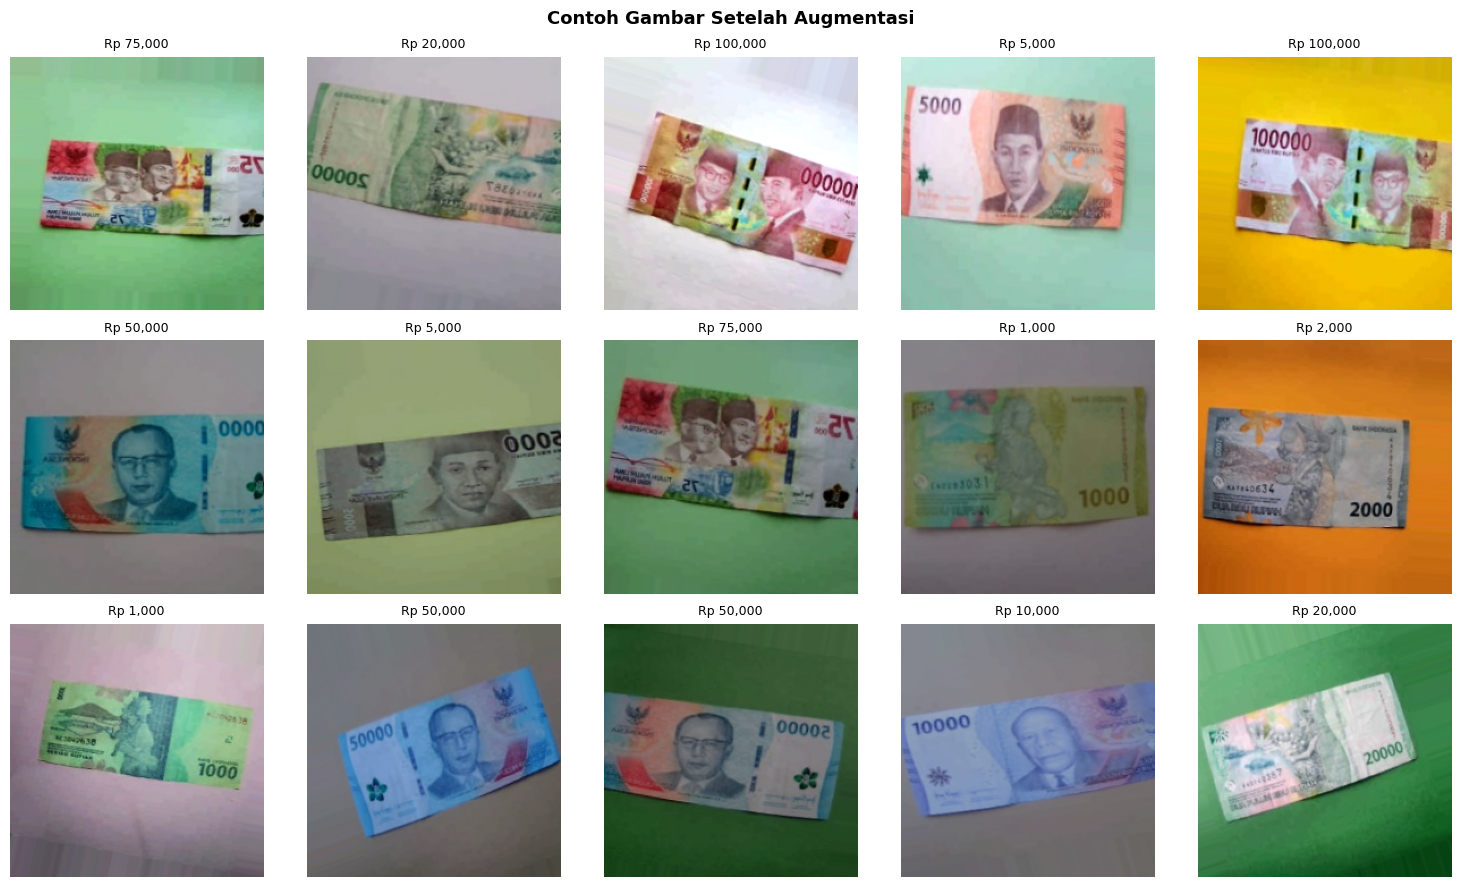

In [6]:
# Visualisasi augmentasi
sample_images, sample_labels = next(train_generator)
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_images[i])
    nominal = idx_to_class[str(np.argmax(sample_labels[i]))]
    ax.set_title(f'Rp {int(nominal):,}', fontsize=9)
    ax.axis('off')
plt.suptitle('Contoh Gambar Setelah Augmentasi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## MODELING

In [ ]:
# BANGUN MODEL TRANSFER LEARNING MOBILENETV2

NUM_CLASSES = len(class_names)
print(f'Jumlah kelas: {NUM_CLASSES}  →  {class_names}')

def build_model(num_classes, img_shape=IMG_SHAPE):
    base_model = MobileNetV2(
        weights='imagenet', include_top=False, input_shape=img_shape
    )
    base_model.trainable = False  # Bekukan di Phase 1

    inputs  = keras.Input(shape=img_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs, name='RupiahDetector'), base_model

model, base_model = build_model(NUM_CLASSES)
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Jumlah kelas: 8  →  ['1000', '2000', '5000', '10000', '20000', '50000', '75000', '100000']


Model: "RupiahDetector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,049,288 (11.63 MB)

 Trainable params: 790,280 (3.01 MB)

 Non-trainable params: 2,259,008 (8.62 MB)

#### TRAINING PHASE 1 - CLASSIFIER HEAD

In [8]:
print('PHASE 1: Training Classifier Head (base FROZEN)...')

callbacks_p1 = [
    ModelCheckpoint(MODEL_SAVE_PATH, monitor='val_accuracy',
                    save_best_only=True, mode='max', verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=7,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-7, verbose=1),
]

history_p1 = model.fit(
    train_generator, epochs=15,
    validation_data=val_generator,
    callbacks=callbacks_p1, verbose=1
)

best_p1 = max(history_p1.history['val_accuracy'])
print(f'\n Phase 1 selesai!  Best val_accuracy: {best_p1*100:.2f}%')

PHASE 1: Training Classifier Head (base FROZEN)...
Epoch 1/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.5411 - loss: 1.4111
Epoch 1: val_accuracy improved from None to 0.98715, saving model to ../modell/rupiah_model.h5



Epoch 1: finished saving model to ../modell/rupiah_model.h5
397/397 ━━━━━━━━━━━━━━━━━━━━ 164s 403ms/step - accuracy: 0.7454 - loss: 0.7921 - val_accuracy: 0.9871 - val_loss: 0.1157 - learning_rate: 1.0000e-04
Epoch 2/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.9305 - loss: 0.2419
Epoch 2: val_accuracy improved from 0.98715 to 0.99523, saving model to ../modell/rupiah_model.h5



Epoch 2: finished saving model to ../modell/rupiah_model.h5
397/397 ━━━━━━━━━━━━━━━━━━━━ 158s 398ms/step - accuracy: 0.9425 - loss: 0.2017 - val_accuracy: 0.9952 - val_loss: 0.0375 - learning_rate: 1.0000e-04
Epoch 3/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.9656 - loss: 0.1253
Epoch 3: val_accuracy improved from 0.99523 to 0.99669, saving model to ../modell/rupiah_model.h5



Epoch 3: finished saving model to ../modell/rupiah_model.h5
397/397 ━━━━━━━━━━━━━━━━━━━━ 158s 397ms/step - accuracy: 0.9676 - loss: 0.1167 - val_accuracy: 0.9967 - val_loss: 0.0250 - learning_rate: 1.0000e-04
Epoch 4/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 582ms/step - accuracy: 0.9729 - loss: 0.0896
Epoch 4: val_accuracy did not improve from 0.99669
397/397 ━━━━━━━━━━━━━━━━━━━━ 254s 640ms/step - accuracy: 0.9759 - loss: 0.0830 - val_accuracy: 0.9949 - val_loss: 0.0214 - learning_rate: 1.0000e-04
Epoch 5/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.9822 - loss: 0.0651
Epoch 5: val_accuracy did not improve from 0.99669
397/397 ━━━━━━━━━━━━━━━━━━━━ 154s 388ms/step - accuracy: 0.9832 - loss: 0.0605 - val_accuracy: 0.9967 - val_loss: 0.0133 - learning_rate: 1.0000e-04
Epoch 6/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.9828 - loss: 0.0550
Epoch 6: val_accuracy improved from 0.99669 to 0.99816, saving model to ../modell/rupiah_model.h5



Epoch 6: finished saving model to ../modell/rupiah_model.h5
397/397 ━━━━━━━━━━━━━━━━━━━━ 157s 395ms/step - accuracy: 0.9850 - loss: 0.0507 - val_accuracy: 0.9982 - val_loss: 0.0099 - learning_rate: 1.0000e-04
Epoch 7/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.9864 - loss: 0.0465
Epoch 7: val_accuracy did not improve from 0.99816
397/397 ━━━━━━━━━━━━━━━━━━━━ 158s 399ms/step - accuracy: 0.9862 - loss: 0.0460 - val_accuracy: 0.9974 - val_loss: 0.0102 - learning_rate: 1.0000e-04
Epoch 8/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9868 - loss: 0.0429
Epoch 8: val_accuracy did not improve from 0.99816
397/397 ━━━━━━━━━━━━━━━━━━━━ 614s 2s/step - accuracy: 0.9891 - loss: 0.0367 - val_accuracy: 0.9971 - val_loss: 0.0097 - learning_rate: 1.0000e-04
Epoch 9/15
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9873 - loss: 0.0394
Epoch 9: val_accuracy did not improve from 0.99816
397/397 ━━━━━━━━━━━━━━━━━━━━ 722s 2s/step - accuracy: 0.9878 - loss: 0.0372 - val_ac

### TRAINING PHASE 2 - FINE TUNNING 

In [9]:
print( 'PHASE 2: Fine-tuning 30 layer terakhir MobileNetV2...')

base_model.trainable = True
FINE_TUNE_AT = len(base_model.layers) - 30
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE / 10),  # LR 10x lebih kecil
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_p2 = [
    ModelCheckpoint(MODEL_SAVE_PATH, monitor='val_accuracy',
                    save_best_only=True, mode='max', verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=3, min_lr=1e-8, verbose=1),
]

history_p2 = model.fit(
    train_generator, epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks_p2, verbose=1
)

best_p2 = max(history_p2.history['val_accuracy'])
print(f'\n Phase 2 selesai!  Best val_accuracy : {best_p2*100:.2f}%')
print(f'   Peningkatan dari Phase 1             : +{(best_p2-best_p1)*100:.2f}%')

PHASE 2: Fine-tuning 30 layer terakhir MobileNetV2...
Epoch 1/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step - accuracy: 0.8054 - loss: 0.5765
Epoch 1: val_accuracy improved from None to 0.99082, saving model to ../modell/rupiah_model.h5



Epoch 1: finished saving model to ../modell/rupiah_model.h5
397/397 ━━━━━━━━━━━━━━━━━━━━ 232s 564ms/step - accuracy: 0.8708 - loss: 0.3855 - val_accuracy: 0.9908 - val_loss: 0.0268 - learning_rate: 1.0000e-05
Epoch 2/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 501ms/step - accuracy: 0.9587 - loss: 0.1418
Epoch 2: val_accuracy improved from 0.99082 to 0.99633, saving model to ../modell/rupiah_model.h5



Epoch 2: finished saving model to ../modell/rupiah_model.h5
397/397 ━━━━━━━━━━━━━━━━━━━━ 221s 556ms/step - accuracy: 0.9634 - loss: 0.1228 - val_accuracy: 0.9963 - val_loss: 0.0123 - learning_rate: 1.0000e-05
Epoch 3/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step - accuracy: 0.9729 - loss: 0.0823
Epoch 3: val_accuracy did not improve from 0.99633
397/397 ━━━━━━━━━━━━━━━━━━━━ 265s 562ms/step - accuracy: 0.9775 - loss: 0.0727 - val_accuracy: 0.9956 - val_loss: 0.0106 - learning_rate: 1.0000e-05
Epoch 4/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 502ms/step - accuracy: 0.9857 - loss: 0.0536
Epoch 4: val_accuracy improved from 0.99633 to 0.99669, saving model to ../modell/rupiah_model.h5



Epoch 4: finished saving model to ../modell/rupiah_model.h5
397/397 ━━━━━━━━━━━━━━━━━━━━ 223s 561ms/step - accuracy: 0.9861 - loss: 0.0522 - val_accuracy: 0.9967 - val_loss: 0.0101 - learning_rate: 1.0000e-05
Epoch 5/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 508ms/step - accuracy: 0.9885 - loss: 0.0408
Epoch 5: val_accuracy did not improve from 0.99669
397/397 ━━━━━━━━━━━━━━━━━━━━ 223s 563ms/step - accuracy: 0.9887 - loss: 0.0388 - val_accuracy: 0.9967 - val_loss: 0.0095 - learning_rate: 1.0000e-05
Epoch 6/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.9899 - loss: 0.0356
Epoch 6: val_accuracy improved from 0.99669 to 0.99706, saving model to ../modell/rupiah_model.h5



Epoch 6: finished saving model to ../modell/rupiah_model.h5
397/397 ━━━━━━━━━━━━━━━━━━━━ 215s 542ms/step - accuracy: 0.9900 - loss: 0.0324 - val_accuracy: 0.9971 - val_loss: 0.0094 - learning_rate: 1.0000e-05
Epoch 7/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - accuracy: 0.9931 - loss: 0.0229
Epoch 7: val_accuracy did not improve from 0.99706
397/397 ━━━━━━━━━━━━━━━━━━━━ 206s 519ms/step - accuracy: 0.9935 - loss: 0.0237 - val_accuracy: 0.9967 - val_loss: 0.0086 - learning_rate: 1.0000e-05
Epoch 8/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.9936 - loss: 0.0204
Epoch 8: val_accuracy improved from 0.99706 to 0.99743, saving model to ../modell/rupiah_model.h5



Epoch 8: finished saving model to ../modell/rupiah_model.h5
397/397 ━━━━━━━━━━━━━━━━━━━━ 193s 487ms/step - accuracy: 0.9939 - loss: 0.0208 - val_accuracy: 0.9974 - val_loss: 0.0083 - learning_rate: 1.0000e-05
Epoch 9/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.9954 - loss: 0.0168
Epoch 9: val_accuracy improved from 0.99743 to 0.99780, saving model to ../modell/rupiah_model.h5



Epoch 9: finished saving model to ../modell/rupiah_model.h5
397/397 ━━━━━━━━━━━━━━━━━━━━ 194s 488ms/step - accuracy: 0.9956 - loss: 0.0160 - val_accuracy: 0.9978 - val_loss: 0.0073 - learning_rate: 1.0000e-05
Epoch 10/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.9956 - loss: 0.0148
Epoch 10: val_accuracy did not improve from 0.99780
397/397 ━━━━━━━━━━━━━━━━━━━━ 192s 483ms/step - accuracy: 0.9954 - loss: 0.0151 - val_accuracy: 0.9974 - val_loss: 0.0072 - learning_rate: 1.0000e-05
Epoch 11/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.9958 - loss: 0.0131
Epoch 11: val_accuracy did not improve from 0.99780
397/397 ━━━━━━━━━━━━━━━━━━━━ 200s 503ms/step - accuracy: 0.9960 - loss: 0.0131 - val_accuracy: 0.9971 - val_loss: 0.0081 - learning_rate: 1.0000e-05
Epoch 12/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.9949 - loss: 0.0132
Epoch 12: val_accuracy did not improve from 0.99780
397/397 ━━━━━━━━━━━━━━━━━━━━ 204s 513ms/step - accuracy: 0.9967 - los


Epoch 16: finished saving model to ../modell/rupiah_model.h5
397/397 ━━━━━━━━━━━━━━━━━━━━ 191s 482ms/step - accuracy: 0.9970 - loss: 0.0087 - val_accuracy: 0.9982 - val_loss: 0.0052 - learning_rate: 1.0000e-05
Epoch 17/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.9988 - loss: 0.0051
Epoch 17: val_accuracy did not improve from 0.99816
397/397 ━━━━━━━━━━━━━━━━━━━━ 194s 488ms/step - accuracy: 0.9986 - loss: 0.0053 - val_accuracy: 0.9982 - val_loss: 0.0048 - learning_rate: 1.0000e-05
Epoch 18/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.9978 - loss: 0.0066
Epoch 18: val_accuracy did not improve from 0.99816
397/397 ━━━━━━━━━━━━━━━━━━━━ 196s 493ms/step - accuracy: 0.9977 - loss: 0.0067 - val_accuracy: 0.9982 - val_loss: 0.0042 - learning_rate: 1.0000e-05
Epoch 19/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.9989 - loss: 0.0044
Epoch 19: val_accuracy improved from 0.99816 to 0.99853, saving model to ../modell/rupiah_model.h5



Epoch 19: finished saving model to ../modell/rupiah_model.h5
397/397 ━━━━━━━━━━━━━━━━━━━━ 191s 480ms/step - accuracy: 0.9987 - loss: 0.0046 - val_accuracy: 0.9985 - val_loss: 0.0049 - learning_rate: 1.0000e-05
Epoch 20/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.9980 - loss: 0.0072
Epoch 20: val_accuracy did not improve from 0.99853
397/397 ━━━━━━━━━━━━━━━━━━━━ 169s 425ms/step - accuracy: 0.9983 - loss: 0.0056 - val_accuracy: 0.9985 - val_loss: 0.0041 - learning_rate: 1.0000e-05
Epoch 21/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.9985 - loss: 0.0052
Epoch 21: val_accuracy did not improve from 0.99853

Epoch 21: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
397/397 ━━━━━━━━━━━━━━━━━━━━ 169s 425ms/step - accuracy: 0.9989 - loss: 0.0042 - val_accuracy: 0.9982 - val_loss: 0.0043 - learning_rate: 1.0000e-05
Epoch 22/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.9981 - loss: 0.0059
Epoch 22: val_accuracy did not improve fr

## TRAINING HISTORY & EVALUASI

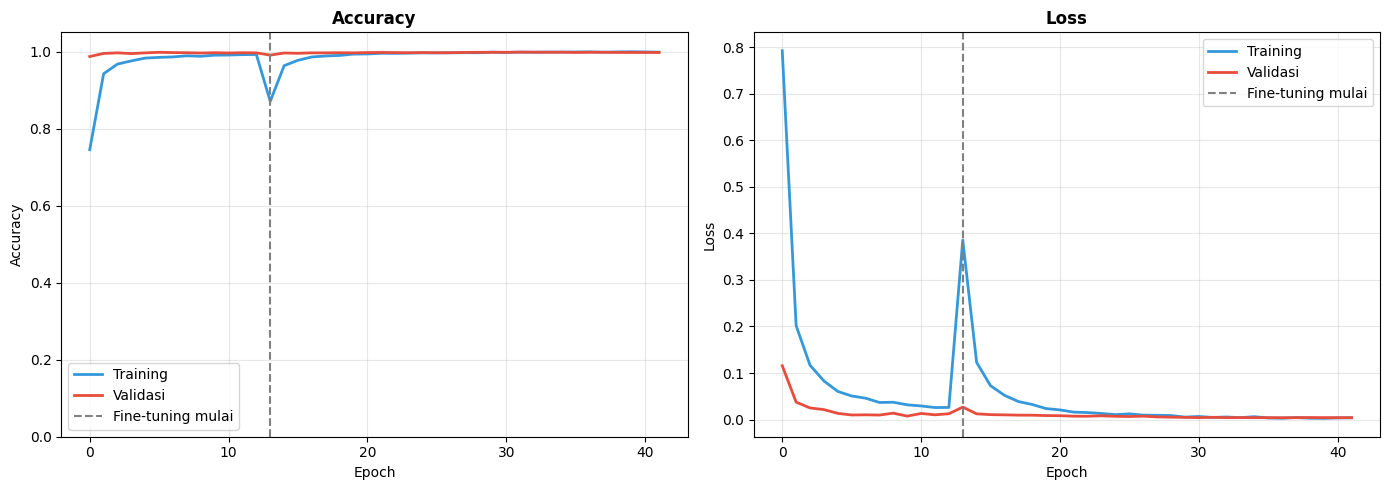

In [10]:
# Gabungkan history dua phase
acc      = history_p1.history['accuracy']     + history_p2.history['accuracy']
val_acc  = history_p1.history['val_accuracy'] + history_p2.history['val_accuracy']
loss_h   = history_p1.history['loss']         + history_p2.history['loss']
val_loss = history_p1.history['val_loss']     + history_p2.history['val_loss']
p1_end   = len(history_p1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (tr, vl, title) in zip(axes, [
    (acc,    val_acc,  'Accuracy'),
    (loss_h, val_loss, 'Loss'),
]):
    ax.plot(tr, label='Training', color='#3498DB', lw=2)
    ax.plot(vl, label='Validasi',  color='#E74C3C', lw=2)
    ax.axvline(x=p1_end, color='gray', ls='--', label='Fine-tuning mulai')
    ax.set_title(f'{title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(title)
    ax.legend(); ax.grid(True, alpha=0.3)
    if title == 'Accuracy': ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('../modell/training_history.png', dpi=100, bbox_inches='tight')
plt.show()

## EVALUASI PADA TEST SET

86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 229ms/step - accuracy: 0.9952 - loss: 0.0167

 HASIL EVALUASI TEST SET:
   Test Loss     : 0.0167
   Test Accuracy : 99.52%
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 240ms/step


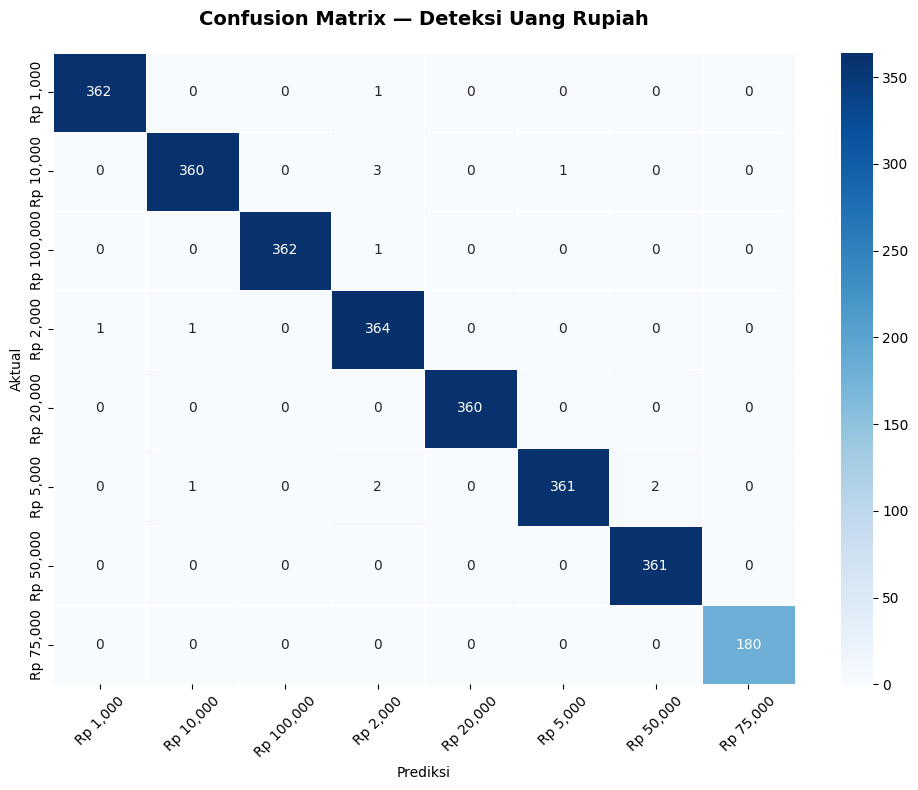


 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    Rp 1,000       1.00      1.00      1.00       363
   Rp 10,000       0.99      0.99      0.99       364
  Rp 100,000       1.00      1.00      1.00       363
    Rp 2,000       0.98      0.99      0.99       366
   Rp 20,000       1.00      1.00      1.00       360
    Rp 5,000       1.00      0.99      0.99       366
   Rp 50,000       0.99      1.00      1.00       361
   Rp 75,000       1.00      1.00      1.00       180

    accuracy                           1.00      2723
   macro avg       1.00      1.00      1.00      2723
weighted avg       1.00      1.00      1.00      2723



In [ ]:
# EVALUASI PADA TEST SET


best_model = keras.models.load_model(MODEL_SAVE_PATH)
test_loss, test_accuracy = best_model.evaluate(test_generator, verbose=1)

print(f'\n HASIL EVALUASI TEST SET:')
print(f'   Test Loss     : {test_loss:.4f}')
print(f'   Test Accuracy : {test_accuracy*100:.2f}%')

# Confusion Matrix
test_generator.reset()
y_pred = np.argmax(best_model.predict(test_generator, verbose=1), axis=1)
y_true = test_generator.classes
``
sorted_cls    = sorted(class_indices, key=class_indices.get)
display_lbls  = [f'Rp {int(c):,}' for c in sorted_cls]

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=display_lbls, yticklabels=display_lbls, lw=0.5)
plt.title('Confusion Matrix — Deteksi Uang Rupiah',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Prediksi'); plt.ylabel('Aktual')
plt.xticks(rotation=45); plt.tight_layout()
plt.savefig('../model/confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

print('\n CLASSIFICATION REPORT:')
print('=' * 70)
print(classification_report(y_true, y_pred, target_names=display_lbls))